
# Macro-Regime-Conditioned FX Carry Strategy

This notebook keeps the validated static FX carry strategy unchanged and uses macro/risk indicators
to classify the **current market regime**, rather than trying to predict whether next month's return
will be positive.

## Research question

> Can a transparent macro-risk regime improve the carry strategy by changing how risk is allocated
> during stressed environments?

The baseline remains:

- forward-implied carry signal;
- long the highest-carry currencies and short the lowest;
- inverse-volatility weighting;
- 10% portfolio volatility target;
- monthly rebalancing;
- realistic bid/ask and swap-roll costs.

The macro extension tests three responses:

1. **Total-risk scaling:** reduce the whole carry portfolio in stressed regimes.
2. **EM-risk trimming:** retain G10 carry but reduce EM currency positions during stress.
3. **Combined defensive portfolio:** apply both a modest total-risk reduction and an EM trim.

No return-probability classifier is used. The regime score is constructed from observable market
stress indicators using expanding historical standardisation, so each date uses only information
available at that time.


## 1. Environment and project paths

In [1]:

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# ---------------------------------------------------------------------
# Locate the shared repository root independently of notebook location.
# The correct root contains both strategy/ and data/raw/.
# ---------------------------------------------------------------------
START = Path.cwd().resolve()

def locate_repository(start: Path) -> Path:
    candidates = [start, *start.parents]

    # Also inspect direct children and parents' direct children. This helps
    # when the notebook lives in a personal folder such as <repo>/vidhi/.
    expanded = list(candidates)
    for candidate in candidates:
        if candidate.exists():
            try:
                expanded.extend(
                    child for child in candidate.iterdir()
                    if child.is_dir()
                )
            except PermissionError:
                pass

    seen = set()
    for candidate in expanded:
        candidate = candidate.resolve()
        if candidate in seen:
            continue
        seen.add(candidate)

        if (
            (candidate / "strategy").is_dir()
            and (candidate / "data" / "raw").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root containing both "
        "'strategy/' and 'data/raw/'. Set REPO_ROOT manually in this cell."
    )

REPO_ROOT = locate_repository(START)
sys.path.insert(0, str(REPO_ROOT))

DATA_DIR = REPO_ROOT / "data" / "raw"

# Keep extension outputs outside strategy/ and cesare/outputs/.
# When the notebook is under <repo>/vidhi or <repo>/vidhi/notebooks,
# results will be written to <repo>/vidhi/outputs.
if START.name.lower() == "notebooks":
    PERSONAL_ROOT = START.parent
elif REPO_ROOT in START.parents or START == REPO_ROOT:
    PERSONAL_ROOT = START
else:
    PERSONAL_ROOT = REPO_ROOT / "vidhi"

OUTPUT_DIR = PERSONAL_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root :", REPO_ROOT)
print("Raw data folder :", DATA_DIR)
print("Output folder   :", OUTPUT_DIR)
print("Strategy exists :", (REPO_ROOT / "strategy").exists())


Repository root : C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL
Raw data folder : C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL\data\raw
Output folder   : C:\Users\vidhi\OneDrive\Desktop\Project lab\Summer\FX_Carry_26_Summer_PL\vidhi\outputs
Strategy exists : True


## 2. Imports and regime parameters

In [2]:

import re
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from strategy import run

# Expanding-history requirement for regime standardisation.
MINIMUM_HISTORY_MONTHS = 36

# Regime thresholds applied to the composite stress score.
RISK_ON_THRESHOLD = -0.50
RISK_OFF_THRESHOLD = 0.50
EXTREME_RISK_THRESHOLD = 1.25

# Total portfolio exposure by regime.
TOTAL_EXPOSURE_MAP = {
    "risk_on": 1.00,
    "neutral": 1.00,
    "risk_off": 0.75,
    "extreme_risk_off": 0.50,
}

# EM weight multiplier by regime.
EM_MULTIPLIER_MAP = {
    "risk_on": 1.00,
    "neutral": 1.00,
    "risk_off": 0.50,
    "extreme_risk_off": 0.25,
}

# Combined strategy uses a milder total scaling because EM is already trimmed.
COMBINED_EXPOSURE_MAP = {
    "risk_on": 1.00,
    "neutral": 1.00,
    "risk_off": 0.90,
    "extreme_risk_off": 0.70,
}

FEATURE_FILES = {
    "global_risk": "global_risk_wide.parquet",
    "em_risk": "em_risk_wide.parquet",
    "macro_market_proxies": "macro_market_proxies_wide.parquet",
    "g10_interest_rates": "g10_interest_rates_wide.parquet",
    "em_interest_rates": "em_interest_rates_wide.parquet",
    "em_onshore_rates": "em_onshore_rates_wide.parquet",
    "g10_rates_gaps": "g10_rates_gaps_wide.parquet",
    "usd_riskfree": "usd_riskfree_wide.parquet",
}


## 3. Run and reconcile the validated team baseline

In [3]:

base = run()

print(base)
print("\nBaseline configuration:")
display(pd.Series(base.config.describe(), name="value").to_frame())

print("\nBaseline summary:")
baseline_summary = base.summary()
display(baseline_summary.round(4))

print(
    f"\nOne-sided turnover per rebalance: {base.turnover:.4f}\n"
    f"Annualised cost drag:             {base.cost_drag:.4%}\n"
    f"Universe size:                    {len(base.universe)}\n"
    f"Evaluation window:                {base.window}"
)

# Reconcile with the committed ALL-book target when the file is present.
committed_path = REPO_ROOT / "cesare" / "outputs" / "strategy_summary_stats.csv"

if committed_path.exists():
    committed = pd.read_csv(committed_path, index_col=0)
    got_net = float(base.summary(benchmark=None).loc["ALL_net", "sharpe"])
    expected_net = float(committed.loc["ALL_net", "sharpe"])
    difference = abs(got_net - expected_net)

    print(
        f"Reconciliation: net Sharpe {got_net:.4f} "
        f"versus committed {expected_net:.4f} "
        f"-> {'OK' if difference < 5e-4 else 'MISMATCH'}"
    )

    if difference >= 5e-4:
        raise RuntimeError(
            "Baseline reconciliation failed. Stop here and repair the "
            "environment before interpreting any overlay results."
        )
else:
    print(
        "Committed summary file was not found. Run "
        "'python strategy/tests/test_reconciliation.py' before using results."
    )


<StrategyResult 'ALL' | 27 ccy | 2007-05-01->2026-06-30 | Sharpe gross 0.628 net 0.466>

Baseline configuration:


,value
universe,ALL
tenor,1M
signal,carry
n_buckets,None
weighting,inv_vol
max_leg_share,0.4
vol_window,60
rebal,ME
vol_target,0.1
lev_cap,4.0



Baseline summary:


,start,end,n_days,ann_return,ann_vol,daily_variance,skew,excess_kurtosis,sharpe,max_drawdown,VaR_95,VaR_99,CVaR_95,CVaR_99,hit_rate,best_day,worst_day,autocorr_1d,cagr,sortino,calmar,info_ratio
ALL_gross,2007-05-01,2026-06-30,5001,0.07029,0.111848,0.00005,-0.652152,4.579734,0.628442,-0.267829,0.010594,0.021711,0.017392,0.029186,0.544091,0.041328,-0.04906,0.010659,0.066103,0.860703,0.246809,0.497304
ALL_net,2007-05-01,2026-06-30,5001,0.052143,0.111914,0.00005,-0.648005,4.543499,0.465923,-0.293185,0.010661,0.02188,0.017493,0.029199,0.538292,0.041328,-0.04906,0.007721,0.046927,0.634117,0.16006,0.337642



One-sided turnover per rebalance: 0.6755
Annualised cost drag:             1.8147%
Universe size:                    27
Evaluation window:                (Timestamp('2007-05-01 00:00:00'), Timestamp('2026-06-30 00:00:00'))
Reconciliation: net Sharpe 0.4659 versus committed 0.4659 -> OK



## 4. Load shared macro and risk panels

The loader is reused from the current working notebook. It handles string indices, date columns,
MultiIndex files, Bloomberg missing-value strings, duplicate dates and mixed trading calendars.


In [4]:
def read_wide_parquet(path: Path) -> pd.DataFrame:
    frame = pd.read_parquet(path)

    print(f"\nLoading: {path.name}")
    print("Index type:", type(frame.index))
    print("Index name:", frame.index.name)
    print("First index values:", frame.index[:3].tolist())
    print("First columns:", frame.columns[:5].tolist())

    # Handle MultiIndex first.
    if isinstance(frame.index, pd.MultiIndex):
        date_level = None

        for level_number in range(frame.index.nlevels):
            values = frame.index.get_level_values(level_number)
            parsed = pd.to_datetime(values, errors="coerce")

            if parsed.notna().mean() >= 0.80:
                date_level = level_number
                break

        if date_level is not None:
            frame.index = pd.to_datetime(
                frame.index.get_level_values(date_level),
                errors="coerce",
            )

    # Try converting an existing non-default index.
    elif not isinstance(frame.index, pd.RangeIndex):
        parsed_index = pd.to_datetime(
            frame.index,
            errors="coerce",
        )

        if parsed_index.notna().mean() >= 0.80:
            frame.index = parsed_index

    # Search for a date column when the index is still not datetime.
    if not isinstance(frame.index, pd.DatetimeIndex):
        possible_names = {
            "date",
            "datetime",
            "timestamp",
            "time",
            "asof_date",
            "observation_date",
            "index",
            "__index_level_0__",
        }

        selected_date_column = None

        for column in frame.columns:
            normalized_name = str(column).strip().lower()

            if normalized_name in possible_names:
                selected_date_column = column
                break

        # As a fallback, inspect columns for date-like values.
        if selected_date_column is None:
            for column in frame.columns:
                parsed = pd.to_datetime(
                    frame[column],
                    errors="coerce",
                )

                if parsed.notna().mean() >= 0.80:
                    selected_date_column = column
                    break

        if selected_date_column is not None:
            frame[selected_date_column] = pd.to_datetime(
                frame[selected_date_column],
                errors="coerce",
            )
            frame = frame.set_index(selected_date_column)

    if not isinstance(frame.index, pd.DatetimeIndex):
        raise ValueError(
            f"{path.name}: could not identify the date field.\n"
            f"Index type: {type(frame.index)}\n"
            f"Index name: {frame.index.name}\n"
            f"Index sample: {frame.index[:5].tolist()}\n"
            f"Columns: {frame.columns[:20].tolist()}"
        )

    frame = frame.loc[frame.index.notna()].copy()
    frame.index = frame.index.normalize()
    frame = frame.sort_index()
    frame = frame.groupby(level=0).last()

    frame = frame.apply(pd.to_numeric, errors="coerce")
    frame = frame.dropna(axis=1, how="all")
    frame = frame.dropna(axis=0, how="all")

    return frame


# ---------------------------------------------------------------------
# Actually load and combine the macro files.
# ---------------------------------------------------------------------
feature_frames = []
loading_report = []

for group_name, filename in FEATURE_FILES.items():
    path = DATA_DIR / filename

    if not path.exists():
        loading_report.append(
            {
                "group": group_name,
                "file": filename,
                "status": "missing",
                "rows": 0,
                "columns": 0,
            }
        )
        continue

    try:
        frame = read_wide_parquet(path)

        frame.columns = [
            f"{group_name}__{column}"
            for column in frame.columns
        ]

        feature_frames.append(frame)

        loading_report.append(
            {
                "group": group_name,
                "file": filename,
                "status": "loaded",
                "rows": len(frame),
                "columns": frame.shape[1],
            }
        )

    except Exception as error:
        loading_report.append(
            {
                "group": group_name,
                "file": filename,
                "status": f"error: {error}",
                "rows": 0,
                "columns": 0,
            }
        )

loading_report = pd.DataFrame(loading_report)
display(loading_report)

if not feature_frames:
    raise RuntimeError(
        "No macro files loaded successfully. Inspect loading_report."
    )

market_daily = pd.concat(
    feature_frames,
    axis=1,
    join="outer",
).sort_index()

market_daily = market_daily.loc[
    ~market_daily.index.duplicated(keep="last")
]

market_daily = market_daily.dropna(how="all")

print("\nCombined daily panel:", market_daily.shape)
print(
    "Date range:",
    market_daily.index.min(),
    "to",
    market_daily.index.max(),
)
print(
    "All-empty rows:",
    int(market_daily.isna().all(axis=1).sum()),
)

display(market_daily.tail())


Loading: global_risk_wide.parquet
Index type: <class 'pandas.core.indexes.base.Index'>
Index name: date
First index values: [datetime.date(2007, 1, 1), datetime.date(2007, 1, 2), datetime.date(2007, 1, 3)]
First columns: [('BCOM Index', 'PX_LAST'), ('CL1 Comdty', 'PX_LAST'), ('CO1 Comdty', 'PX_LAST'), ('DXY Curncy', 'PX_LAST'), ('HG1 Comdty', 'PX_LAST')]

Loading: em_risk_wide.parquet
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index name: date
First index values: [Timestamp('2007-01-01 00:00:00'), Timestamp('2007-01-02 00:00:00'), Timestamp('2007-01-03 00:00:00')]
First columns: [('JPEIGLSP Index', 'PX_LAST')]

Loading: macro_market_proxies_wide.parquet
Index type: <class 'pandas.core.indexes.base.Index'>
Index name: date
First index values: [datetime.date(2007, 1, 1), datetime.date(2007, 1, 2), datetime.date(2007, 1, 3)]
First columns: [('BCOM Index', 'PX_LAST'), ('BFCIUS Index', 'PX_LAST'), ('CL1 Comdty', 'PX_LAST'), ('CO1 Comdty', 'PX_LAST'), ('CPI YOY Index'

,group,file,status,rows,columns
0,global_risk,global_risk_wide.parquet,loaded,5087,19
1,em_risk,em_risk_wide.parquet,loaded,5091,1
2,macro_market_proxies,macro_market_proxies_wide.parquet,loaded,5155,24
3,g10_interest_rates,g10_interest_rates_wide.parquet,loaded,5087,81
4,em_interest_rates,em_interest_rates_wide.parquet,loaded,5087,34
5,em_onshore_rates,em_onshore_rates_wide.parquet,loaded,7127,16
6,g10_rates_gaps,g10_rates_gaps_wide.parquet,loaded,5091,4
7,usd_riskfree,usd_riskfree_wide.parquet,loaded,5091,1



Combined daily panel: (7127, 180)
Date range: 2007-01-01 00:00:00 to 2026-07-06 00:00:00
All-empty rows: 0


,"global_risk__('BCOM Index', 'PX_LAST')","global_risk__('CL1 Comdty', 'PX_LAST')","global_risk__('CO1 Comdty', 'PX_LAST')","global_risk__('DXY Curncy', 'PX_LAST')","global_risk__('HG1 Comdty', 'PX_LAST')","global_risk__('JPMVXYEM Index', 'PX_LAST')","global_risk__('JPMVXYG7 Index', 'PX_LAST')","global_risk__('JPMVXYGL Index', 'PX_LAST')","global_risk__('MOVE Index', 'PX_LAST')","global_risk__('MXEF Index', 'PX_LAST')","global_risk__('MXWO Index', 'PX_LAST')","global_risk__('NDX Index', 'PX_LAST')","global_risk__('RTY Index', 'PX_LAST')","global_risk__('SPX Index', 'PX_LAST')","global_risk__('USGG10YR Index', 'PX_LAST')","global_risk__('USGG2YR Index', 'PX_LAST')","global_risk__('USYC2Y10 Index', 'PX_LAST')","global_risk__('VIX Index', 'PX_LAST')","global_risk__('XAU Curncy', 'PX_LAST')","em_risk__('JPEIGLSP Index', 'PX_LAST')","macro_market_proxies__('BCOM Index', 'PX_LAST')","macro_market_proxies__('BFCIUS Index', 'PX_LAST')","macro_market_proxies__('CL1 Comdty', 'PX_LAST')","macro_market_proxies__('CO1 Comdty', 'PX_LAST')","macro_market_proxies__('CPI YOY Index', 'PX_LAST')","macro_market_proxies__('CPURNSA Index', 'PX_LAST')","macro_market_proxies__('FEDL01 Index', 'PX_LAST')","macro_market_proxies__('GACGB10 Index', 'PX_LAST')","macro_market_proxies__('GACGB2 Index', 'PX_LAST')","macro_market_proxies__('GCAN10YR Index', 'PX_LAST')","macro_market_proxies__('GCAN2YR Index', 'PX_LAST')","macro_market_proxies__('GDBR10 Index', 'PX_LAST')","macro_market_proxies__('GDBR2 Index', 'PX_LAST')","macro_market_proxies__('GDP CUR$ Index', 'PX_LAST')","macro_market_proxies__('GJGB10 Index', 'PX_LAST')","macro_market_proxies__('GJGB2 Index', 'PX_LAST')","macro_market_proxies__('GUKG10 Index', 'PX_LAST')","macro_market_proxies__('GUKG2 Index', 'PX_LAST')","macro_market_proxies__('HG1 Comdty', 'PX_LAST')","macro_market_proxies__('M2% YOY Index', 'PX_LAST')","macro_market_proxies__('SOFRRATE Index', 'PX_LAST')","macro_market_proxies__('USGG10YR Index', 'PX_LAST')","macro_market_proxies__('USGG2YR Index', 'PX_LAST')","macro_market_proxies__('XAU Curncy', 'PX_LAST')","g10_interest_rates__('ADBB12M Curncy', 'PX_LAST')","g10_interest_rates__('ADBB1M Curncy', 'PX_LAST')","g10_interest_rates__('ADBB3M Curncy', 'PX_LAST')","g10_interest_rates__('ADDR1Z Curncy', 'PX_LAST')","g10_interest_rates__('ADSO1Z Curncy', 'PX_LAST')","g10_interest_rates__('ADSOA Curncy', 'PX_LAST')","g10_interest_rates__('ADSOC Curncy', 'PX_LAST')","g10_interest_rates__('ADSOF Curncy', 'PX_LAST')","g10_interest_rates__('BP0001M Index', 'PX_LAST')","g10_interest_rates__('BP0001W Index', 'PX_LAST')","g10_interest_rates__('BP0003M Index', 'PX_LAST')","g10_interest_rates__('BP0012M Index', 'PX_LAST')","g10_interest_rates__('BPSWS1Z Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSA Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSC Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSF Curncy', 'PX_LAST')",...,"g10_interest_rates__('USOSFRC Curncy', 'PX_LAST')","g10_interest_rates__('USOSFRF Curncy', 'PX_LAST')","g10_interest_rates__('USSO1Z Curncy', 'PX_LAST')","g10_interest_rates__('USSOA Curncy', 'PX_LAST')","g10_interest_rates__('USSOC Curncy', 'PX_LAST')","em_interest_rates__('BCCDIO Curncy', 'PX_LAST')","em_interest_rates__('BCSWAPD Curncy', 'PX_LAST')","em_interest_rates__('BZSTSETA Index', 'PX_LAST')","em_interest_rates__('CHSWP1 Index', 'PX_LAST')","em_interest_rates__('CHSWPC Index', 'PX_LAST')","em_interest_rates__('CLTN30DS Curncy', 'PX_LAST')","em_interest_rates__('COMM1YR Index', 'PX_LAST')","em_interest_rates__('CORRRMIN Index', 'PX_LAST')","em_interest_rates__('DTF RATE Index', 'PX_LAST')","em_interest_rates__('IDBIRATE Index', 'PX_LAST')","em_interest_rates__('IDRE1MO Index', 'PX_LAST')","em_interest_rates__('IHSWOOA Curncy', 'PX_LAST')","em_interest_rates__('JIBA12M Index', 'PX_LAST')","em_interest_rates__('JIBA1M Index', 'PX_LAST')","em_interest_rates__('JIBA3M Index', 'PX_LAST')","em_interest_rates__('JIIN1M Index', 'PX_LAST')","em_interest_rates__('KLIB1M Index

## 5. Convert market data to month-end state variables

In [5]:

def monthly_market_changes(daily_panel: pd.DataFrame) -> pd.DataFrame:
    monthly_last = daily_panel.resample("ME").last()
    transformed = {}

    for column in monthly_last.columns:
        series = monthly_last[column].astype(float)
        valid = series.dropna()
        if valid.empty:
            continue

        # Positive price/index series: log change.
        # Rates/spreads/nonpositive series: first difference.
        if (valid > 0).all():
            transformed[column] = np.log(series).diff()
        else:
            transformed[column] = series.diff()

    monthly = pd.DataFrame(transformed)
    monthly = monthly.replace([np.inf, -np.inf], np.nan)
    monthly.index = (
        pd.to_datetime(monthly.index)
        .to_period("M")
        .to_timestamp("M")
    )
    return monthly.dropna(how="all")


macro_monthly = monthly_market_changes(market_daily)

print("Monthly macro panel:", macro_monthly.shape)
print("Date range:", macro_monthly.index.min(), "to", macro_monthly.index.max())
display(macro_monthly.tail())


Monthly macro panel: (234, 180)
Date range: 2007-02-28 00:00:00 to 2026-07-31 00:00:00


,"global_risk__('BCOM Index', 'PX_LAST')","global_risk__('CL1 Comdty', 'PX_LAST')","global_risk__('CO1 Comdty', 'PX_LAST')","global_risk__('DXY Curncy', 'PX_LAST')","global_risk__('HG1 Comdty', 'PX_LAST')","global_risk__('JPMVXYEM Index', 'PX_LAST')","global_risk__('JPMVXYG7 Index', 'PX_LAST')","global_risk__('JPMVXYGL Index', 'PX_LAST')","global_risk__('MOVE Index', 'PX_LAST')","global_risk__('MXEF Index', 'PX_LAST')","global_risk__('MXWO Index', 'PX_LAST')","global_risk__('NDX Index', 'PX_LAST')","global_risk__('RTY Index', 'PX_LAST')","global_risk__('SPX Index', 'PX_LAST')","global_risk__('USGG10YR Index', 'PX_LAST')","global_risk__('USGG2YR Index', 'PX_LAST')","global_risk__('USYC2Y10 Index', 'PX_LAST')","global_risk__('VIX Index', 'PX_LAST')","global_risk__('XAU Curncy', 'PX_LAST')","em_risk__('JPEIGLSP Index', 'PX_LAST')","macro_market_proxies__('BCOM Index', 'PX_LAST')","macro_market_proxies__('BFCIUS Index', 'PX_LAST')","macro_market_proxies__('CL1 Comdty', 'PX_LAST')","macro_market_proxies__('CO1 Comdty', 'PX_LAST')","macro_market_proxies__('CPI YOY Index', 'PX_LAST')","macro_market_proxies__('CPURNSA Index', 'PX_LAST')","macro_market_proxies__('FEDL01 Index', 'PX_LAST')","macro_market_proxies__('GACGB10 Index', 'PX_LAST')","macro_market_proxies__('GACGB2 Index', 'PX_LAST')","macro_market_proxies__('GCAN10YR Index', 'PX_LAST')","macro_market_proxies__('GCAN2YR Index', 'PX_LAST')","macro_market_proxies__('GDBR10 Index', 'PX_LAST')","macro_market_proxies__('GDBR2 Index', 'PX_LAST')","macro_market_proxies__('GDP CUR$ Index', 'PX_LAST')","macro_market_proxies__('GJGB10 Index', 'PX_LAST')","macro_market_proxies__('GJGB2 Index', 'PX_LAST')","macro_market_proxies__('GUKG10 Index', 'PX_LAST')","macro_market_proxies__('GUKG2 Index', 'PX_LAST')","macro_market_proxies__('HG1 Comdty', 'PX_LAST')","macro_market_proxies__('M2% YOY Index', 'PX_LAST')","macro_market_proxies__('SOFRRATE Index', 'PX_LAST')","macro_market_proxies__('USGG10YR Index', 'PX_LAST')","macro_market_proxies__('USGG2YR Index', 'PX_LAST')","macro_market_proxies__('XAU Curncy', 'PX_LAST')","g10_interest_rates__('ADBB12M Curncy', 'PX_LAST')","g10_interest_rates__('ADBB1M Curncy', 'PX_LAST')","g10_interest_rates__('ADBB3M Curncy', 'PX_LAST')","g10_interest_rates__('ADDR1Z Curncy', 'PX_LAST')","g10_interest_rates__('ADSO1Z Curncy', 'PX_LAST')","g10_interest_rates__('ADSOA Curncy', 'PX_LAST')","g10_interest_rates__('ADSOC Curncy', 'PX_LAST')","g10_interest_rates__('ADSOF Curncy', 'PX_LAST')","g10_interest_rates__('BP0001M Index', 'PX_LAST')","g10_interest_rates__('BP0001W Index', 'PX_LAST')","g10_interest_rates__('BP0003M Index', 'PX_LAST')","g10_interest_rates__('BP0012M Index', 'PX_LAST')","g10_interest_rates__('BPSWS1Z Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSA Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSC Curncy', 'PX_LAST')","g10_interest_rates__('BPSWSF Curncy', 'PX_LAST')",...,"g10_interest_rates__('USOSFRC Curncy', 'PX_LAST')","g10_interest_rates__('USOSFRF Curncy', 'PX_LAST')","g10_interest_rates__('USSO1Z Curncy', 'PX_LAST')","g10_interest_rates__('USSOA Curncy', 'PX_LAST')","g10_interest_rates__('USSOC Curncy', 'PX_LAST')","em_interest_rates__('BCCDIO Curncy', 'PX_LAST')","em_interest_rates__('BCSWAPD Curncy', 'PX_LAST')","em_interest_rates__('BZSTSETA Index', 'PX_LAST')","em_interest_rates__('CHSWP1 Index', 'PX_LAST')","em_interest_rates__('CHSWPC Index', 'PX_LAST')","em_interest_rates__('CLTN30DS Curncy', 'PX_LAST')","em_interest_rates__('COMM1YR Index', 'PX_LAST')","em_interest_rates__('CORRRMIN Index', 'PX_LAST')","em_interest_rates__('DTF RATE Index', 'PX_LAST')","em_interest_rates__('IDBIRATE Index', 'PX_LAST')","em_interest_rates__('IDRE1MO Index', 'PX_LAST')","em_interest_rates__('IHSWOOA Curncy', 'PX_LAST')","em_interest_rates__('JIBA12M Index', 'PX_LAST')","em_interest_rates__('JIBA1M Index', 'PX_LAST')","em_interest_rates__('JIBA3M Index', 'PX_LAST')","em_interest_rates__('JIIN1M Index', 'PX_LAST')","em_interest_rates__('KLIB1M Index


## 6. Select economically interpretable regime indicators

The regime score intentionally uses a compact set of market-stress concepts rather than every
available series.

The selection rules search the loaded column names for:

- FX volatility: JPM G7, global and EM volatility indices;
- rates volatility: MOVE;
- broad dollar strength: DXY;
- equity risk: VIX and broad/EM equity indices;
- credit stress: spread, high-yield, CDS or EMBI-like series;
- commodity/growth stress: oil, copper and broad commodities.

Stress directions are explicit:

- increases in volatility, dollar strength and credit spreads increase risk;
- declines in equities, oil, copper and broad commodities increase risk.


In [6]:

def first_matching_columns(
    columns,
    include_patterns,
    exclude_patterns=None,
    maximum=3,
):
    exclude_patterns = exclude_patterns or []
    matches = []

    for column in columns:
        text = str(column).lower()

        if not any(re.search(pattern, text) for pattern in include_patterns):
            continue
        if any(re.search(pattern, text) for pattern in exclude_patterns):
            continue

        matches.append(column)
        if len(matches) >= maximum:
            break

    return matches


columns = list(macro_monthly.columns)

indicator_groups = OrderedDict({
    "fx_volatility": {
        "columns": first_matching_columns(
            columns,
            [r"jpmvxy", r"fx.*vol", r"currency.*vol"],
            maximum=3,
        ),
        "direction": 1.0,
    },
    "rates_volatility": {
        "columns": first_matching_columns(
            columns,
            [r"move index", r"rates.*vol", r"bond.*vol"],
            maximum=2,
        ),
        "direction": 1.0,
    },
    "equity_volatility": {
        "columns": first_matching_columns(
            columns,
            [r"vix index", r"v2x", r"vstoxx"],
            maximum=2,
        ),
        "direction": 1.0,
    },
    "broad_dollar": {
        "columns": first_matching_columns(
            columns,
            [r"dxy", r"bloomberg dollar", r"bbdxy"],
            maximum=2,
        ),
        "direction": 1.0,
    },
    "credit_stress": {
        "columns": first_matching_columns(
            columns,
            [r"spread", r"cds", r"embi", r"high.?yield", r"oas"],
            exclude_patterns=[r"swap.*spread"],
            maximum=3,
        ),
        "direction": 1.0,
    },
    "equity_growth": {
        "columns": first_matching_columns(
            columns,
            [r"mxef index", r"spx index", r"msci", r"equity"],
            exclude_patterns=[r"vol"],
            maximum=3,
        ),
        "direction": -1.0,
    },
    "oil_growth": {
        "columns": first_matching_columns(
            columns,
            [r"cl1 comdty", r"co1 comdty", r"oil", r"brent", r"wti"],
            maximum=2,
        ),
        "direction": -1.0,
    },
    "industrial_growth": {
        "columns": first_matching_columns(
            columns,
            [r"hg1 comdty", r"copper", r"bcom index", r"commodity"],
            maximum=2,
        ),
        "direction": -1.0,
    },
})

selection_rows = []
for group_name, specification in indicator_groups.items():
    for column in specification["columns"]:
        selection_rows.append(
            {
                "indicator_group": group_name,
                "column": column,
                "stress_direction": specification["direction"],
            }
        )

indicator_selection = pd.DataFrame(selection_rows)
display(indicator_selection)

if indicator_selection.empty:
    raise RuntimeError(
        "No regime indicators were matched. Inspect macro_monthly.columns "
        "and update the keyword patterns in this cell."
    )


,indicator_group,column,stress_direction
0,fx_volatility,"global_risk__('JPMVXYEM Index', 'PX_LAST')",1.0
1,fx_volatility,"global_risk__('JPMVXYG7 Index', 'PX_LAST')",1.0
2,fx_volatility,"global_risk__('JPMVXYGL Index', 'PX_LAST')",1.0
3,rates_volatility,"global_risk__('MOVE Index', 'PX_LAST')",1.0
4,equity_volatility,"global_risk__('VIX Index', 'PX_LAST')",1.0
5,broad_dollar,"global_risk__('DXY Curncy', 'PX_LAST')",1.0
6,credit_stress,"g10_interest_rates__('CDSO1Z Curncy', 'PX_LAST')",1.0
7,credit_stress,"g10_interest_rates__('CDSOA Curncy', 'PX_LAST')",1.0
8,credit_stress,"g10_interest_rates__('CDSOC Curncy', 'PX_LAST')",1.0
9,equity_growth,"global_risk__('MXEF Index', 'PX_LAST')",-1.0


## 7. Build expanding macro-risk z-scores and regime labels

In [7]:

def expanding_z_score(
    series: pd.Series,
    minimum_history: int = 36,
) -> pd.Series:
    historical_mean = (
        series.expanding(min_periods=minimum_history)
        .mean()
        .shift(1)
    )
    historical_std = (
        series.expanding(min_periods=minimum_history)
        .std()
        .shift(1)
        .replace(0, np.nan)
    )
    return (series - historical_mean) / historical_std


group_scores = {}

for group_name, specification in indicator_groups.items():
    group_columns = specification["columns"]
    direction = specification["direction"]

    if not group_columns:
        continue

    z_panel = pd.concat(
        {
            column: expanding_z_score(
                macro_monthly[column],
                minimum_history=MINIMUM_HISTORY_MONTHS,
            )
            for column in group_columns
        },
        axis=1,
    )

    # Winsorise only after using historical means/stds, to prevent one
    # extreme observation from dominating the composite.
    z_panel = z_panel.clip(lower=-3.0, upper=3.0)
    group_scores[group_name] = direction * z_panel.mean(axis=1)

group_score_panel = pd.DataFrame(group_scores)

# Require at least three available indicator groups.
available_group_count = group_score_panel.notna().sum(axis=1)
macro_risk_score = (
    group_score_panel.mean(axis=1)
    .where(available_group_count >= 3)
    .rename("macro_risk_score")
)

regime = pd.Series(
    np.select(
        [
            macro_risk_score >= EXTREME_RISK_THRESHOLD,
            macro_risk_score >= RISK_OFF_THRESHOLD,
            macro_risk_score <= RISK_ON_THRESHOLD,
        ],
        [
            "extreme_risk_off",
            "risk_off",
            "risk_on",
        ],
        default="neutral",
    ),
    index=macro_risk_score.index,
    name="regime",
).where(macro_risk_score.notna())

regime_panel = pd.concat(
    [macro_risk_score, regime, group_score_panel],
    axis=1,
)

print("Regime observations:")
display(regime.value_counts(dropna=False).to_frame("months"))
display(regime_panel.dropna(subset=["macro_risk_score"]).tail(12))


Regime observations:


,months
regime,
neutral,137
NaN,37
risk_on,28
risk_off,26
extreme_risk_off,6


,macro_risk_score,regime,fx_volatility,rates_volatility,equity_volatility,broad_dollar,credit_stress,equity_growth,oil_growth,industrial_growth
date,,,,,,,,,,
2025-07-31,0.005431,neutral,-0.820936,-0.724586,-0.011752,1.371551,0.055451,-0.288415,-0.593707,1.055842
2025-08-31,-0.203011,neutral,-0.101682,-0.039771,-0.373824,-1.020522,-0.090565,-0.222999,0.647176,-0.421902
2025-09-30,-0.281988,neutral,-0.634343,-0.115125,0.243031,-0.027003,-0.384504,-0.855079,0.195402,-0.678281
2025-10-31,-0.205268,neutral,-0.509314,-0.925465,0.288458,0.885584,-0.546824,-0.492550,0.242896,-0.584927
2025-11-30,-0.006501,neutral,0.095427,0.200260,-0.289010,-0.186943,-0.047374,0.286669,0.319723,-0.430756
2025-12-31,-0.198152,neutral,0.145029,-0.444026,-0.396562,-0.545152,0.059612,-0.127573,0.267886,-0.544427
2026-01-31,-0.353811,neutral,0.914604,-0.455873,0.661949,-0.638904,0.020705,-0.762873,-1.272025,-1.298069
2026-02-28,0.123943,neutral,-0.495790,1.266299,0.555042,0.257018,0.054476,-0.245738,-0.232471,-0.167289
2026-03-31,0.407117,neutral,1.370909,1.579766,1.033136,1.040456,0.024976,1.865557,-3.000000,-0.657867


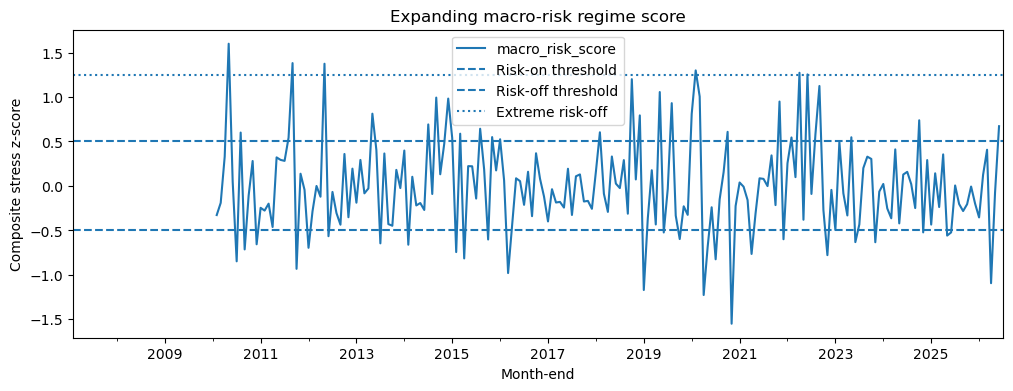

In [8]:

ax = macro_risk_score.plot(
    figsize=(12, 4),
    title="Expanding macro-risk regime score",
)
ax.axhline(RISK_ON_THRESHOLD, linestyle="--", label="Risk-on threshold")
ax.axhline(RISK_OFF_THRESHOLD, linestyle="--", label="Risk-off threshold")
ax.axhline(EXTREME_RISK_THRESHOLD, linestyle=":", label="Extreme risk-off")
ax.set_ylabel("Composite stress z-score")
ax.set_xlabel("Month-end")
ax.legend()
plt.show()



## 8. Validate that the regimes are economically meaningful

This is not a return-prediction model, but the regime labels should still separate market conditions.

The tables below compare:

- the baseline's contemporaneous monthly return by regime;
- volatility and downside frequency by regime;
- subsequent one-month baseline return by current regime.

The forward-return table is diagnostic only. No labels or fitted coefficients are used to construct
the regime.


In [9]:

monthly_base = base.monthly(which="net").rename("baseline_net_return")
monthly_base.index = (
    pd.to_datetime(monthly_base.index)
    .to_period("M")
    .to_timestamp("M")
)

regime_evaluation = pd.concat(
    [
        monthly_base,
        monthly_base.shift(-1).rename("next_month_return"),
        macro_risk_score,
        regime,
    ],
    axis=1,
).dropna(subset=["regime"])

regime_contemporaneous = (
    regime_evaluation
    .groupby("regime", observed=True)
    .agg(
        observations=("baseline_net_return", "size"),
        mean_return=("baseline_net_return", "mean"),
        median_return=("baseline_net_return", "median"),
        volatility=("baseline_net_return", "std"),
        negative_month_rate=(
            "baseline_net_return",
            lambda values: (values < 0).mean(),
        ),
        worst_month=("baseline_net_return", "min"),
        mean_risk_score=("macro_risk_score", "mean"),
    )
)

regime_forward = (
    regime_evaluation
    .dropna(subset=["next_month_return"])
    .groupby("regime", observed=True)
    .agg(
        observations=("next_month_return", "size"),
        mean_next_return=("next_month_return", "mean"),
        median_next_return=("next_month_return", "median"),
        next_negative_rate=(
            "next_month_return",
            lambda values: (values < 0).mean(),
        ),
        worst_next_return=("next_month_return", "min"),
    )
)

print("Baseline performance during each regime:")
display(regime_contemporaneous.round(4))

print("Baseline performance in the month after each regime signal:")
display(regime_forward.round(4))


Baseline performance during each regime:


,observations,mean_return,median_return,volatility,negative_month_rate,worst_month,mean_risk_score
regime,,,,,,,
extreme_risk_off,6,-0.0172,-0.0109,0.0364,0.5000,-0.0658,1.3635
neutral,137,0.0068,0.0037,0.0309,0.4307,-0.1118,-0.0413
risk_off,26,-0.0043,0.0017,0.0467,0.4615,-0.1398,0.7551
risk_on,28,0.0047,0.0003,0.0257,0.4286,-0.0416,-0.7688


Baseline performance in the month after each regime signal:


,observations,mean_next_return,median_next_return,next_negative_rate,worst_next_return
regime,,,,,
extreme_risk_off,6,-0.0166,0.0020,0.5000,-0.1398
neutral,137,0.0047,0.0026,0.4380,-0.1118
risk_off,25,0.0062,0.0002,0.4400,-0.0658
risk_on,28,0.0056,0.0028,0.3929,-0.0391


## 9. Convert regimes into unlagged portfolio instructions

In [10]:

total_exposure = (
    regime.map(TOTAL_EXPOSURE_MAP)
    .astype(float)
    .rename("total_regime_exposure")
)

combined_exposure = (
    regime.map(COMBINED_EXPOSURE_MAP)
    .astype(float)
    .rename("combined_regime_exposure")
)

em_multiplier = (
    regime.map(EM_MULTIPLIER_MAP)
    .astype(float)
    .rename("em_regime_multiplier")
)

regime_instruction_panel = pd.concat(
    [
        macro_risk_score,
        regime,
        total_exposure,
        em_multiplier,
        combined_exposure,
    ],
    axis=1,
)

display(regime_instruction_panel.dropna().tail(15))
display(
    regime_instruction_panel[
        ["total_regime_exposure", "em_regime_multiplier", "combined_regime_exposure"]
    ].describe().round(4)
)


,macro_risk_score,regime,total_regime_exposure,em_regime_multiplier,combined_regime_exposure
date,,,,,
2025-04-30,0.354951,neutral,1.00,1.0,1.0
2025-05-31,-0.557722,risk_on,1.00,1.0,1.0
2025-06-30,-0.522091,risk_on,1.00,1.0,1.0
2025-07-31,0.005431,neutral,1.00,1.0,1.0
2025-08-31,-0.203011,neutral,1.00,1.0,1.0
2025-09-30,-0.281988,neutral,1.00,1.0,1.0
2025-10-31,-0.205268,neutral,1.00,1.0,1.0
2025-11-30,-0.006501,neutral,1.00,1.0,1.0
2025-12-31,-0.198152,neutral,1.00,1.0,1.0


,total_regime_exposure,em_regime_multiplier,combined_regime_exposure
count,197.0000,197.0000,197.0000
mean,0.9518,0.9112,0.9777
std,0.1166,0.2060,0.0598
min,0.5000,0.2500,0.7000
25%,1.0000,1.0000,1.0000
50%,1.0000,1.0000,1.0000
75%,1.0000,1.0000,1.0000
max,1.0000,1.0000,1.0000



## 10. Create an EM-only weight overlay

The total-risk strategy uses the native `exposure` hook.

The EM-trim strategy uses `weight_overlay` to multiply only EM currency positions by the regime
multiplier. G10 positions are left unchanged. This tests whether macro stress is more useful for
altering portfolio composition than for abandoning carry altogether.

The regime instruction is supplied unlagged. The shared strategy engine remains responsible for
its execution conventions and transaction costs.


In [11]:

# Standard G10 currencies used by the project.
G10_CURRENCIES = {
    "AUD", "CAD", "CHF", "EUR", "GBP",
    "JPY", "NOK", "NZD", "SEK",
}

def monthly_signal_to_daily(
    signal: pd.Series,
    daily_index: pd.DatetimeIndex,
) -> pd.Series:
    month_key = (
        pd.to_datetime(daily_index)
        .to_period("M")
        .to_timestamp("M")
    )
    aligned = signal.reindex(month_key)
    aligned.index = daily_index
    return aligned


def make_em_trim_overlay(monthly_multiplier: pd.Series):
    def overlay(weights: pd.DataFrame, ctx):
        out = weights.copy()
        daily_multiplier = monthly_signal_to_daily(
            monthly_multiplier,
            out.index,
        )

        # Before the regime history begins, preserve the baseline.
        daily_multiplier = daily_multiplier.fillna(1.0)

        em_columns = [
            currency for currency in out.columns
            if currency not in G10_CURRENCIES
        ]

        if not em_columns:
            raise RuntimeError(
                "No EM currencies were found in the strategy weight panel."
            )

        out.loc[:, em_columns] = (
            out.loc[:, em_columns]
            .mul(daily_multiplier, axis=0)
        )
        return out

    return overlay


em_trim_overlay = make_em_trim_overlay(em_multiplier)


## 11. Run the regime-conditioned strategy variants

In [12]:

total_risk_result = run(
    exposure=total_exposure,
    name="macro_total_risk_scaling",
)

em_trim_result = run(
    weight_overlay=em_trim_overlay,
    name="macro_em_trim",
)

combined_result = run(
    exposure=combined_exposure,
    weight_overlay=em_trim_overlay,
    name="macro_combined_defensive",
)

results = {
    "static_baseline": base,
    "total_risk_scaling": total_risk_result,
    "em_trim": em_trim_result,
    "combined_defensive": combined_result,
}

print("All regime-conditioned strategy variants completed.")


All regime-conditioned strategy variants completed.


## 12. Full-window and regime-sample performance comparison

In [13]:

def comparison_table(result_dictionary: dict) -> pd.DataFrame:
    rows = []

    for strategy_name, result in result_dictionary.items():
        summary = result.summary(benchmark=None)

        for return_type in ["gross", "net"]:
            row_name = next(
                index for index in summary.index
                if str(index).lower().endswith(f"_{return_type}")
            )
            row = summary.loc[row_name].copy()
            row["strategy"] = strategy_name
            row["return_type"] = return_type
            row["turnover"] = result.turnover
            row["cost_drag"] = result.cost_drag
            rows.append(row)

    return pd.DataFrame(rows).set_index(["strategy", "return_type"])


preferred_columns = [
    "ann_return",
    "ann_vol",
    "sharpe",
    "sortino",
    "calmar",
    "max_drawdown",
    "skew",
    "hit_rate",
    "turnover",
    "cost_drag",
]

full_summary = comparison_table(results)

print("Full common-window comparison:")
display(
    full_summary[
        [column for column in preferred_columns if column in full_summary.columns]
    ].round(4)
)

first_regime_date = regime.first_valid_index()
if first_regime_date is None:
    raise RuntimeError("No valid macro regime date exists.")

regime_sample_results = {
    name: result.reslice(first_regime_date, None)
    for name, result in results.items()
}
regime_sample_summary = comparison_table(regime_sample_results)

print("Regime evaluation starts:", first_regime_date.date())
display(
    regime_sample_summary[
        [column for column in preferred_columns if column in regime_sample_summary.columns]
    ].round(4)
)


Full common-window comparison:


ann_return  ann_vol  sharpe  sortino  calmar  max_drawdown    skew  hit_rate  turnover  cost_drag
strategy           return_type                                                                                                   
static_baseline    gross            0.0703   0.1118  0.6284   0.8607  0.2468       -0.2678 -0.6522    0.5441    0.6755     0.0181
                   net              0.0521   0.1119  0.4659   0.6341  0.1601       -0.2932 -0.6480    0.5383    0.6755     0.0181
total_risk_scaling gross            0.0696   0.1066  0.6529   0.8959  0.2907       -0.2270 -0.6584    0.5441    0.7096     0.0184
                   net              0.0512   0.1067  0.4803   0.6547  0.1861       -0.2503 -0.6547    0.5381    0.7096     0.0184
em_trim            gross            0.0924   0.1053  0.8779   1.2284  0.4599       -0.1973 -0.5095    0.5521    0.7248     0.0190
                   net              0.0734   0.1054  0.6970   0.9681  0.3408       -0.2061 -0.5071    0.5459    0.7248     0.0190
combined_defensive gross            0.0910   0.1029  0.8849   1.2375  0.4635       -0.1931 -0.5289    0.5521    0.7183     0.0186
                   net              0.0724   0.1030  0.7036   0.9769  0.3441       -0.2017 -0.5267    0.5459    0.7183     0.0186

Regime evaluation starts: 2010-02-28


ann_return  ann_vol  sharpe  sortino  calmar  max_drawdown    skew  hit_rate  turnover  cost_drag
strategy           return_type                                                                                                   
static_baseline    gross            0.0684   0.1109  0.6166   0.8429  0.2397       -0.2678 -0.6730    0.5455    0.6864     0.0176
                   net              0.0508   0.1110  0.4577   0.6217  0.1557       -0.2932 -0.6697    0.5406    0.6864     0.0176
total_risk_scaling gross            0.0676   0.1047  0.6456   0.8843  0.2822       -0.2270 -0.6835    0.5455    0.7265     0.0178
                   net              0.0498   0.1048  0.4748   0.6458  0.1808       -0.2503 -0.6809    0.5404    0.7265     0.0178
em_trim            gross            0.0944   0.1031  0.9153   1.2839  0.4720       -0.1973 -0.4961    0.5549    0.7443     0.0186
                   net              0.0758   0.1032  0.7343   1.0221  0.3542       -0.2061 -0.4955    0.5495    0.7443     0.0186
combined_defensive gross            0.0928   0.1002  0.9253   1.2974  0.4747       -0.1931 -0.5183    0.5549    0.7367     0.0181
                   net              0.0746   0.1003  0.7438   1.0349  0.3572       -0.2017 -0.5180    0.5495    0.7367     0.0181

## 13. Wealth and drawdown comparison

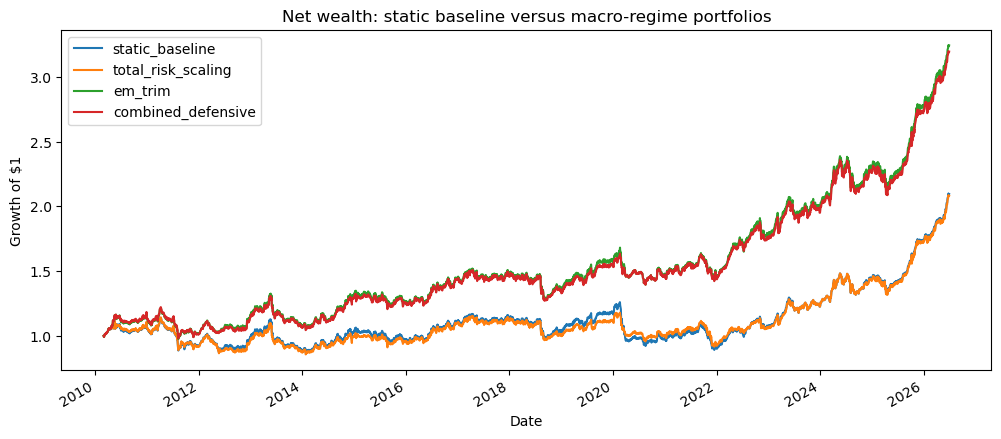

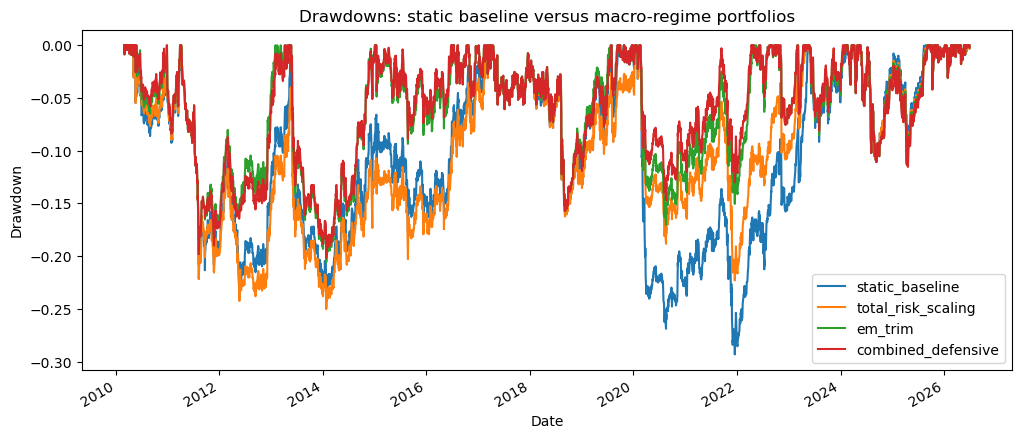

In [14]:

net_returns = pd.concat(
    {
        name: result.net
        for name, result in results.items()
    },
    axis=1,
).loc[first_regime_date:].dropna(how="all")

wealth = (1.0 + net_returns.fillna(0.0)).cumprod()
wealth = wealth.div(wealth.iloc[0])

wealth.plot(
    figsize=(12, 5),
    title="Net wealth: static baseline versus macro-regime portfolios",
)
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.show()


def drawdown_from_returns(returns: pd.Series) -> pd.Series:
    path = (1.0 + returns.fillna(0.0)).cumprod()
    return path.div(path.cummax()).sub(1.0)


drawdowns = net_returns.apply(drawdown_from_returns)
drawdowns.plot(
    figsize=(12, 5),
    title="Drawdowns: static baseline versus macro-regime portfolios",
)
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.show()


## 14. Stress-period and worst-month diagnostics

In [15]:

monthly_strategy_returns = pd.concat(
    {
        name: result.monthly(which="net")
        for name, result in results.items()
    },
    axis=1,
)
monthly_strategy_returns.index = (
    pd.to_datetime(monthly_strategy_returns.index)
    .to_period("M")
    .to_timestamp("M")
)
monthly_strategy_returns = monthly_strategy_returns.loc[first_regime_date:]

monthly_diagnostics = pd.concat(
    [
        monthly_strategy_returns,
        regime_instruction_panel,
    ],
    axis=1,
)

worst_dates = (
    monthly_strategy_returns["static_baseline"]
    .nsmallest(15)
    .index
)

print("Worst 15 static-baseline months:")
display(
    monthly_diagnostics.loc[worst_dates]
    .sort_values("static_baseline")
    .round(4)
)

stress_months = monthly_diagnostics[
    monthly_diagnostics["regime"].isin(
        ["risk_off", "extreme_risk_off"]
    )
]

stress_summary = stress_months[
    list(results.keys())
].agg(["count", "mean", "median", "std", "min"]).T

print("Performance during macro stress regimes:")
display(stress_summary.round(4))


Worst 15 static-baseline months:


,static_baseline,total_risk_scaling,em_trim,combined_defensive,macro_risk_score,regime,total_regime_exposure,em_regime_multiplier,combined_regime_exposure
date,,,,,,,,,
2020-03-31,-0.1398,-0.0722,-0.0709,-0.0512,1.0053,risk_off,0.75,0.50,0.9
2018-08-31,-0.1118,-0.1118,-0.1118,-0.1118,0.2908,neutral,1.00,1.00,1.0
2021-11-30,-0.1003,-0.1003,-0.0437,-0.0437,0.9491,risk_off,0.75,0.50,0.9
2020-02-29,-0.0658,-0.0500,-0.0149,-0.0135,1.2992,extreme_risk_off,0.50,0.25,0.7
2024-08-31,-0.0536,-0.0536,-0.0536,-0.0536,0.0207,neutral,1.00,1.00,1.0
2011-07-31,-0.0530,-0.0530,-0.0530,-0.0530,0.2820,neutral,1.00,1.00,1.0
2013-06-30,-0.0508,-0.0387,-0.0498,-0.0449,0.4040,neutral,1.00,1.00,1.0
2012-05-31,-0.0507,-0.0507,0.0095,0.0095,1.3742,extreme_risk_off,0.50,0.25,0.7
2021-10-31,-0.0502,-0.0502,-0.0502,-0.0502,-0.2151,neutral,1.00,1.00,1.0


Performance during macro stress regimes:


,count,mean,median,std,min
static_baseline,32.0,-0.0067,0.0017,0.0447,-0.1398
total_risk_scaling,32.0,-0.0041,0.0015,0.0386,-0.1003
em_trim,32.0,0.0066,0.0099,0.0292,-0.0709
combined_defensive,32.0,0.0073,0.0101,0.0277,-0.0512



## 15. Composition and cost diagnostics

This section verifies that the EM overlay is actually changing the intended part of the book and
measures the resulting turnover and cost drag.


In [16]:

def average_absolute_exposure(
    weights: pd.DataFrame,
    columns: list[str],
) -> float:
    valid_columns = [column for column in columns if column in weights.columns]
    if not valid_columns:
        return np.nan
    return float(weights[valid_columns].abs().sum(axis=1).mean())


em_currencies = [
    currency for currency in base.weights.columns
    if currency not in G10_CURRENCIES
]
g10_currencies = [
    currency for currency in base.weights.columns
    if currency in G10_CURRENCIES
]

composition_diagnostics = pd.DataFrame(
    {
        "avg_g10_abs_exposure": {
            name: average_absolute_exposure(result.weights, g10_currencies)
            for name, result in results.items()
        },
        "avg_em_abs_exposure": {
            name: average_absolute_exposure(result.weights, em_currencies)
            for name, result in results.items()
        },
        "turnover": {
            name: result.turnover
            for name, result in results.items()
        },
        "annual_cost_drag": {
            name: result.cost_drag
            for name, result in results.items()
        },
    }
)

display(composition_diagnostics.round(4))


,avg_g10_abs_exposure,avg_em_abs_exposure,turnover,annual_cost_drag
static_baseline,0.9438,2.2880,0.6755,0.0181
total_risk_scaling,0.9051,2.2123,0.7096,0.0184
em_trim,0.9438,2.1127,0.7248,0.0190
combined_defensive,0.9257,2.0815,0.7183,0.0186


## 16. Threshold robustness

In [17]:

# This is a diagnostic sweep over nearby total-exposure maps.
# It is not intended for selecting the single best in-sample cell.

robustness_maps = {
    "mild": {
        "risk_on": 1.00,
        "neutral": 1.00,
        "risk_off": 0.90,
        "extreme_risk_off": 0.75,
    },
    "base_case": TOTAL_EXPOSURE_MAP,
    "strong": {
        "risk_on": 1.00,
        "neutral": 1.00,
        "risk_off": 0.60,
        "extreme_risk_off": 0.30,
    },
}

robustness_rows = []

for map_name, exposure_map in robustness_maps.items():
    exposure_signal = regime.map(exposure_map).astype(float)
    result = run(
        exposure=exposure_signal,
        name=f"regime_{map_name}",
    ).reslice(first_regime_date, None)

    net_row_name = next(
        index for index in result.summary(benchmark=None).index
        if str(index).lower().endswith("_net")
    )
    summary_row = result.summary(benchmark=None).loc[net_row_name]

    robustness_rows.append(
        {
            "mapping": map_name,
            "ann_return": summary_row.get("ann_return", np.nan),
            "ann_vol": summary_row.get("ann_vol", np.nan),
            "sharpe": summary_row.get("sharpe", np.nan),
            "sortino": summary_row.get("sortino", np.nan),
            "calmar": summary_row.get("calmar", np.nan),
            "max_drawdown": summary_row.get("max_drawdown", np.nan),
            "turnover": result.turnover,
            "cost_drag": result.cost_drag,
        }
    )

robustness_table = pd.DataFrame(robustness_rows).set_index("mapping")
display(robustness_table.round(4))


,ann_return,ann_vol,sharpe,sortino,calmar,max_drawdown,turnover,cost_drag
mapping,,,,,,,,
mild,0.0508,0.1080,0.4700,0.6390,0.1768,-0.2597,0.6966,0.0176
base_case,0.0498,0.1048,0.4748,0.6458,0.1808,-0.2503,0.7265,0.0178
strong,0.0483,0.1025,0.4716,0.6417,0.1742,-0.2526,0.7652,0.0183
